# experiment 1


Selected runs:
auprc     auroc  epoch  seed  timestep
0.373447  0.770488     94     0         1
0.363009  0.753016     35     1         1
0.377469  0.764679     59     2         1
0.382345  0.775329     89     3         1
0.355122  0.752636     62     4         1
0.388768  0.772463     58     0         2
0.385208  0.766522     60     1         2
0.378108  0.763186     87     2         2
0.390922  0.766076     91     3         2
0.378478  0.769356     79     4         2
0.370163  0.768867     55     0         4
0.376685  0.764763     56     1         4
0.372705  0.766493     48     2         4
0.375986  0.765392     86     3         4
0.374956  0.763407     90     4         4
0.363877  0.762593     98     0         8
0.382160  0.766517     57     1         8
0.374329  0.762674     72     2         8
0.368798  0.758103     45     3         8
0.362096  0.756643     51     4         8
0.354942  0.744280     39     0        12
0.378930  0.758148     46     1        12
0.357096  0.759668   

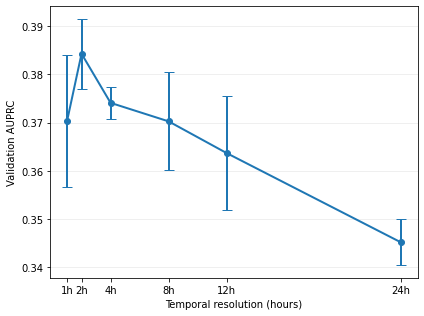

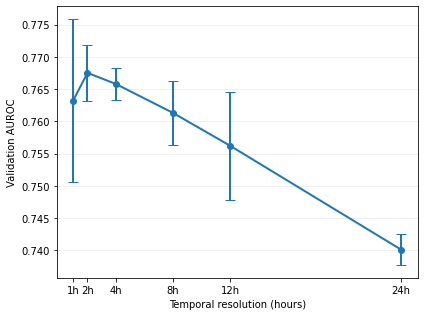

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t


RESULTS_DIR = Path("/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results")
TIMESTEPS = [1, 2, 4, 8, 12, 24]


def load_results():
    rows = []

    for timestep in TIMESTEPS:
        log_dir = RESULTS_DIR / f"{timestep}h" / "keras_logs"

        # Only use seeded runs; ignore the older unseeded CSVs.
        files = sorted(log_dir.glob("*.seed*.csv"))

        for path in files:
            match = re.search(r"seed(\d+)", path.name)
            if match is None:
                continue

            seed = int(match.group(1))

            # Logs are semicolon-separated.
            df = pd.read_csv(path, sep=";")

            # Select checkpoint/epoch by validation AUPRC.
            best_idx = df["val_auprc"].idxmax()
            best = df.loc[best_idx]

            rows.append(
                {
                    "timestep": timestep,
                    "seed": seed,
                    "epoch": int(best["epoch"]),
                    "auprc": best["val_auprc"],
                    # AUROC from the SAME selected epoch.
                    "auroc": best["val_auroc"],
                }
            )

    return pd.DataFrame(rows)


def summarize(df, metric):
    rows = []

    for timestep, group in df.groupby("timestep"):
        values = np.asarray(group[metric].values)
        n = len(values)

        mean = values.mean()
        sd = values.std(ddof=1)
        sem = sd / np.sqrt(n)

        # Two-sided 95% Student-t confidence interval.
        critical = t.ppf(0.975, df=n - 1)
        ci = critical * sem

        rows.append(
            {
                "timestep": timestep,
                "mean": mean,
                "sd": sd,
                "ci95": ci,
                "n": n,
            }
        )

    return pd.DataFrame(rows).sort_values("timestep")


def plot_metric(summary, metric_name, output_file):
    x = np.asarray(summary["timestep"].values)
    y = np.asarray(summary["mean"].values)
    ci = np.asarray(summary["ci95"].values)

    plt.figure(figsize=(6, 4.5))

    plt.errorbar(
        x,
        y,
        yerr=ci,
        marker="o",
        capsize=5,
        linewidth=2,
        markersize=6,
    )

    plt.xlabel("Temporal resolution (hours)")
    plt.ylabel(metric_name)
    plt.xticks(TIMESTEPS, [f"{x}h" for x in TIMESTEPS])

    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    # plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()


df = load_results()

print("\nSelected runs:")
print(df.to_string(index=False))

auprc_summary = summarize(df, "auprc")
auroc_summary = summarize(df, "auroc")

print("\nAUPRC:")
print(auprc_summary.to_string(index=False))

print("\nAUROC:")
print(auroc_summary.to_string(index=False))

plot_metric(
    auprc_summary,
    metric_name="Validation AUPRC",
    output_file="experiment1_auprc_ci.png",
)

plot_metric(
    auroc_summary,
    metric_name="Validation AUROC",
    output_file="experiment1_auroc_ci.png",
)